<div style="display: flex; align-items: center;">

  <!-- Logos -->
  <div style="white-space: nowrap;">
    <img 
      src="https://www.upc.edu/comunicacio/ca/identitat/descarrega-arxius-grafics/fitxers-marca-principal/upc-positiu-p3005.png" 
      width="300"
      style="vertical-align: middle;"
    >
    <img 
      src="https://www.hipotecalowcost.com/wp-content/uploads/2019/08/Logo-CaixaBank.png" 
      width="200"
      style="vertical-align: middle;"
    >
  </div>

  <!-- Texto -->
  <div style="margin-left: auto; margin-right: 100px; text-align: right;">
      <p style="margin: 0;"><b>CaixaBank · Advanced Analytics Program</b></p>
      <p style="margin: 0;"><b>Model Risk & Data Science Training</b></p>
      <p style="margin: 0;">Intelligence Data Science and Artificial Intelligence (IDEAI)</p>
  </div>

</div>

# **XGBoost, AdaBoost y CatBoost**

Comparativa de boosting paso a paso.

In [25]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier, plot_importance, plot_tree

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
    roc_curve)

In [26]:
from pathlib import Path
base_path = Path().resolve()
base_path

df = pd.read_csv(base_path / "../../data/dataset_bancario_clean.csv")

In [27]:
print("Dimensiones:", df.shape)
display(df.head())
display(df.info())

print("Distribución de clases:")
print(y.value_counts())

print("\nProporciones:")
print(y.value_counts(normalize=True))

print("\nValores perdidos por columna:")
print(X.isnull().sum().sort_values(ascending=False).head())

print("\nResumen descriptivo:")
display(X.describe())

Dimensiones: (5000, 32)


,cliente_id,edad,antiguedad_cliente,ingresos_mensuales,situacion_laboral,estado_civil,nivel_estudios,provincia_riesgo,segmento_cliente,num_productos,...,nuevas_cuentas_12m,uso_banca_digital,alertas_fraude_12m,reclamaciones_12m,tiene_hipoteca,tiene_prestamo_personal,tiene_tarjeta_credito,tiene_seguro,score_interno,default
0,1,30,9.9,1826.17,jubilado,soltero,universitarios,bajo,medio,1,...,1,0.611,0,0,0,0,1,1,950,0
1,2,38,9.6,3981.70,temporal,soltero,medios,bajo,alto,3,...,1,0.635,0,1,0,1,1,1,858,0
2,3,57,6.8,2090.93,autonomo,soltero,medios,medio,medio,1,...,1,0.829,0,0,0,0,1,1,912,0
3,4,44,3.1,1611.53,asalariado,casado,universitarios,bajo,medio,1,...,1,0.547,0,0,1,1,0,0,754,0
4,5,53,5.3,4903.26,asalariado,viudo,universitarios,alto,alto,2,...,0,0.777,0,0,0,1,0,1,912,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   cliente_id               5000 non-null   int64  
 1   edad                     5000 non-null   int64  
 2   antiguedad_cliente       5000 non-null   float64
 3   ingresos_mensuales       5000 non-null   float64
 4   situacion_laboral        5000 non-null   object 
 5   estado_civil             5000 non-null   object 
 6   nivel_estudios           5000 non-null   object 
 7   provincia_riesgo         5000 non-null   object 
 8   segmento_cliente         5000 non-null   object 
 9   num_productos            5000 non-null   int64  
 10  saldo_medio_3m           5000 non-null   float64
 11  limite_credito           5000 non-null   float64
 12  deuda_total              5000 non-null   float64
 13  cuota_mensual_prestamos  5000 non-null   float64
 14  utilizacion_credito     

None

Distribución de clases:
default
0    4938
1      62
Name: count, dtype: int64

Proporciones:
default
0    0.9876
1    0.0124
Name: proportion, dtype: float64

Valores perdidos por columna:
edad                  0
antiguedad_cliente    0
ingresos_mensuales    0
situacion_laboral     0
estado_civil          0
dtype: int64

Resumen descriptivo:


,edad,antiguedad_cliente,ingresos_mensuales,num_productos,saldo_medio_3m,limite_credito,deuda_total,cuota_mensual_prestamos,utilizacion_credito,porcentaje_ahorro,...,consultas_credito_6m,nuevas_cuentas_12m,uso_banca_digital,alertas_fraude_12m,reclamaciones_12m,tiene_hipoteca,tiene_prestamo_personal,tiene_tarjeta_credito,tiene_seguro,score_interno
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,42.166400,9.803260,2437.235544,2.926400,2933.208640,8404.098140,11111.227030,275.015806,0.399310,1.208839,...,1.822400,0.884600,0.645025,0.132600,0.355800,0.292000,0.278200,0.734400,0.484400,897.762400
std,11.772614,6.285815,1152.002969,1.440902,2373.233841,5081.446115,7826.124609,222.823294,0.211382,0.746636,...,1.354705,0.942051,0.210085,0.353613,0.596722,0.454728,0.448157,0.441696,0.499807,56.679761
min,18.000000,0.000000,700.000000,1.000000,-3000.000000,500.000000,0.000000,0.000000,0.000000,-1.321000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,596.000000
25%,34.000000,5.275000,1619.542500,2.000000,1362.387500,4946.542500,5869.452500,123.205000,0.236750,0.699750,...,1.000000,0.000000,0.505000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,864.000000
50%,42.000000,8.800000,2193.105000,3.000000,2549.745000,7316.010000,9429.850000,218.845000,0.389000,1.215000,...,2.000000,1.000000,0.650000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,913.000000
75%,50.000000,13.500000,3001.367500,4.000000,4035.370000,10675.990000,14722.760000,363.877500,0.551000,1.715250,...,3.000000,1.000000,0.801000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,950.000000
max,80.000000,40.000000,11377.190000,6.000000,22270.360000,40000.000000,81975.200000,1841.670000,1.000000,4.317000,...,10.000000,6.000000,1.000000,2.000000,5.000000,1.000000,1.000000,1.000000,1.000000,950.000000


#### Visualización de la variable objetivo
 
Es importante comprobar si las clases están equilibradas o desbalanceadas.

Si una clase aparece mucho más que la otra, ciertas métricas como la accuracy pueden resultar engañosas.

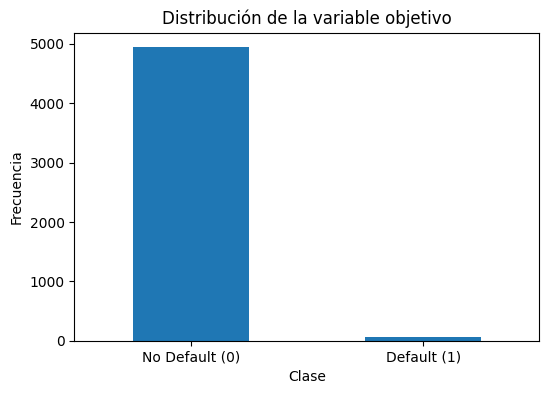

In [29]:
fig, ax = plt.subplots(figsize=(6,4))
y.value_counts().sort_index().plot(kind="bar", ax=ax)
ax.set_title("Distribución de la variable objetivo")
ax.set_xlabel("Clase")
ax.set_ylabel("Frecuencia")
ax.set_xticklabels(["No Default (0)", "Default (1)"], rotation=0)
plt.show()

Este gráfico muestra cuántos casos pertenecen a cada clase.
 
Si las barras tienen alturas parecidas, el problema está relativamente equilibrado.
Si una clase domina claramente, habrá que prestar especial atención a:
 
- `recall`
- `precision`
- `F1-score`
- `AUC-ROC`
 
y no solo a la exactitud global.

In [20]:
columnas_a_excluir = ["default", "cliente_id"]
columnas_presentes_a_excluir = [c for c in columnas_a_excluir if c in df.columns]

X = df.drop(columns=columnas_presentes_a_excluir)
y = df["default"]

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (5000, 30)
Dimensiones de y: (5000,)


In [21]:
variables_numericas = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("\nVariables numéricas:")
print(variables_numericas)
print("\nVariables categóricas:")
print(variables_categoricas)


Variables numéricas:
['edad', 'antiguedad_cliente', 'ingresos_mensuales', 'num_productos', 'saldo_medio_3m', 'limite_credito', 'deuda_total', 'cuota_mensual_prestamos', 'utilizacion_credito', 'porcentaje_ahorro', 'ratio_endeudamiento', 'retrasos_30d_12m', 'retrasos_60d_12m', 'retrasos_90d_12m', 'impagos_previos', 'consultas_credito_6m', 'nuevas_cuentas_12m', 'uso_banca_digital', 'alertas_fraude_12m', 'reclamaciones_12m', 'tiene_hipoteca', 'tiene_prestamo_personal', 'tiene_tarjeta_credito', 'tiene_seguro', 'score_interno']

Variables categóricas:
['situacion_laboral', 'estado_civil', 'nivel_estudios', 'provincia_riesgo', 'segmento_cliente']


#### División en entrenamiento y prueba
 
Separaremos los datos en:
 
- **train**: para entrenar el modelo
- **test**: para evaluar su rendimiento en datos no vistos

Usaremos `stratify=y` para mantener la proporción de clases en ambos conjuntos.

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("\nTamaño train:", X_train.shape)
print("Tamaño test :", X_test.shape)


Tamaño train: (3750, 30)
Tamaño test : (1250, 30)


## **XGBoost**

**XGBoost** significa **Extreme Gradient Boosting**. Es un algoritmo basado en árboles de decisión que construye un modelo final a partir de la suma de muchos árboles pequeños.

La idea principal es:
 
1. se construye un primer árbol
2. se calculan los errores cometidos
3. se construye otro árbol que intenta corregir esos errores
4. el proceso se repite muchas veces
 
En lugar de crear un único árbol muy grande, XGBoost crea muchos árboles pequeños que van corrigiendo progresivamente los errores anteriores.

### ¿Por qué XGBoost es tan potente?
 
XGBoost destaca porque:

- suele tener un rendimiento predictivo muy alto
- maneja relaciones no lineales
- capta interacciones entre variables
- incorpora regularización
- permite controlar el sobreajuste
- ofrece medidas de importancia de variables

Vamos a entrenar un modelo base antes de ajustar hiperparámetros.
 
#### Parámetros importantes de XGBoost

##### `n_estimators`
Número de árboles que se construyen.

- más alto: modelo más complejo
- demasiado alto: más riesgo de sobreajuste y mayor coste computacional
 
##### `max_depth`
Profundidad máxima de cada árbol.
 
- valores pequeños: modelo más simple
- valores grandes: más capacidad, pero más riesgo de memorizar ruido
 
##### `learning_rate`
Controla cuánto contribuye cada árbol nuevo.
 
- pequeño: aprendizaje más lento pero más estable
- grande: entrenamiento más rápido, pero puede empeorar la generalización
 
##### `subsample`
Proporción de observaciones usadas para construir cada árbol.
 
- menor que 1 introduce aleatoriedad
- ayuda a evitar sobreajuste
 
##### `colsample_bytree`
Proporción de variables usadas en cada árbol.
 
- reduce dependencia excesiva de ciertas variables
- también ayuda contra el sobreajuste
 
##### `gamma`
Mejora mínima necesaria para realizar una partición en un nodo.
 
- valores altos hacen el modelo más conservador
 
##### `reg_alpha`
Regularización L1.
 
- puede hacer que algunas contribuciones se reduzcan a cero
- útil cuando hay muchas variables
 
##### `reg_lambda`
Regularización L2.
 
- suaviza los pesos del modelo
- ayuda a controlar complejidad
 
##### `min_child_weight`
Número mínimo efectivo de observaciones que debe haber en una hoja.
 
- si sube, el árbol se vuelve más conservador

En este primer modelo utilizaremos una configuración razonable.

In [31]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

ValueError: DataFrame.dtypes for data must be int, float, bool or category. When categorical type is supplied, the experimental DMatrix parameter`enable_categorical` must be set to `True`.  Invalid columns:situacion_laboral: object, estado_civil: object, nivel_estudios: object, provincia_riesgo: object, segmento_cliente: object

In [23]:
transformador_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

transformador_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", transformador_numerico, variables_numericas),
    ("cat", transformador_categorico, variables_categoricas)
])

## **AdaBoost**

## **CatBoost**

In [24]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

modelo_adaboost = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ))
])

modelo_adaboost.fit(X_train, y_train)
pred_adaboost = modelo_adaboost.predict(X_test)
proba_adaboost = modelo_adaboost.predict_proba(X_test)[:, 1]
print("AdaBoost AUC:", round(roc_auc_score(y_test, proba_adaboost), 4))

AdaBoost AUC: 0.7028
